In [ ]:
import seaborn
import matplotlib.pyplot as plt
import sys
import os
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

In [5]:
import torch
from torch.utils.data import DataLoader

from data.dataset import SUMODataset
from src.blocks.gcn import GCN
from src.blocks.gat import GAT
from src.models.mapEncoder import SpatialEncoder
from src.blocks.gru import TemporalEncoder
from src.models.mapEncoder import SpatioTemporalConditioner
from src.flowMatching import VelocityVectorField, FlowMatchingModel, predict
from src.utils import check_gpu, run_training, dataset_split
from src.models.normalizer import MapNormalizer 

In [2]:
import torch

data = torch.load(
    "/mnt/external1/irene/sumo-stgcn/data/built_dataset/processed/data_273.pt",
    weights_only=False,  # Set to False if loading PyTorch Geometric / custom data objects
)

print(type(data))
print(data)

/mnt/external1/irene/sumo-stgcn/.venv-cuda/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<class 'torch_geometric.data.data.Data'>
Data(x=[234, 7], edge_index=[2, 421], edge_attr=[421, 6], y=[234, 3])


In [ ]:
# import pandas as pd

# # If it's a PyTorch Geometric Data object with node/edge features:
# df = pd.DataFrame(data.x.cpu().numpy())

# # Or if it is a dictionary of 1D/2D tensors:
# df = pd.DataFrame({k: v.cpu().numpy() for k, v in data.items()})

ValueError: Per-column arrays must each be 1-dimensional

In [19]:
!nvidia-smi

Sun Sep 13 15:00:59 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 565.57.01              Driver Version: 565.57.01      CUDA Version: 12.7     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Quadro GV100                   On  |   00000000:21:00.0 Off |                  Off |
| 30%   42C    P2             24W /  250W |       4MiB /  32768MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [20]:
!python -c "import torch; print(torch.version.cuda)"

12.1


In [21]:
import os
import sys
import torch
from torch.utils.data import DataLoader
from pathlib import Path

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

In [24]:
print(ROOT)
print(Path.cwd())

/mnt/external1/irene/sumo-stgcn
/mnt/external1/irene/sumo-stgcn/src


In [25]:
from data.dataset import SUMODataset
from src.blocks.gcn import GCN
from src.blocks.gat import GAT
from src.models.mapEncoder import SpatialEncoder
from src.blocks.gru import TemporalEncoder
from src.models.mapEncoder import SpatioTemporalConditioner
from src.flowMatching import VelocityVectorField, FlowMatchingModel
from src.utils import check_gpu, run_training, dataset_split

# setup
WINDOW = 6
EPOCHS = 200
device = check_gpu()

# Dataset split
dataset = SUMODataset(root=f"{ROOT}/data/built_dataset", window=WINDOW)
train_set, val_set, test_set = dataset_split(dataset, window=WINDOW, train_fraction=0.6, val_fraction=0.2, test_fraction=0.2)

# fuori dal training loop, subito dopo aver creato train_set
sample = train_set[0]   # passa per Subset -> SUMODataset.__getitem__ -> get()
graphs, target = sample
# print("target.shape (accesso diretto):", target.shape)

# print("len(dataset):", len(dataset))
# print("window:", WINDOW)
# print("file .pt trovati:", len(os.listdir(os.path.join("data/built_dataset", "processed"))))

# Build dataloaders
# collate custom to deactivate automatic batching - DataLoader can't batch (list[Data], Tensor)
collate_fn = lambda batch: batch[0]
train_loader = DataLoader(train_set, batch_size=1, shuffle=True, collate_fn=collate_fn) # shuffle only training set
val_loader = DataLoader(val_set, batch_size=1, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_set, batch_size=1, shuffle=False, collate_fn=collate_fn)

# dimensions
node_in_dim = 4 + 3
gcn_out_dim = 16
gat_out_dim = 16 # per-node spatial embedding
temporal_hidden = 32 # cond dimension
feat_dyn_dim = 3

gcn = GCN(hidden_dims=[node_in_dim, 32, gcn_out_dim], dropout_prob=0.1)
gat = GAT(hidden_dims=[gcn_out_dim, gat_out_dim], heads=2, edge_dim=6, dropout_prob=0.1)
spatial_encoder = SpatialEncoder(gcn, gat)
temporal_encoder = TemporalEncoder(in_dim=gat_out_dim, hidden_dim=temporal_hidden, num_layers=1)
conditioner = SpatioTemporalConditioner(spatial_encoder, temporal_encoder)

velocity_field = VelocityVectorField(feat_dyn_dim=feat_dyn_dim, cond_dim=temporal_hidden, hidden_dim=64)

# Instantiate the model
model = FlowMatchingModel(conditioner, velocity_field).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Train model
history = run_training(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=EPOCHS,
    checkpoint_path="checkpoints/second_run.pt",
    print_every=5,
)

Using device: cuda


  0%|          | 1/200 [00:09<32:01,  9.66s/it]

Epoch: 0 | Train Loss: 71551.9105 | Val Loss: 45051.2031


  3%|▎         | 6/200 [00:57<31:13,  9.66s/it]

Epoch: 5 | Train Loss: 21481.7682 | Val Loss: 22087.1621


...

 96%|█████████▌| 191/200 [28:29<01:17,  8.59s/it]

Epoch: 190 | Train Loss: 3861.8308 | Val Loss: 6134.5391


 98%|█████████▊| 196/200 [29:13<00:34,  8.62s/it]

Epoch: 195 | Train Loss: 4578.5845 | Val Loss: 5480.1182


100%|██████████| 200/200 [29:47<00:00,  8.94s/it]


In [36]:
def plot_loss(num_epochs:int, train_loss_values: list, val_loss_values: list, #output_path:str
        ):
        epochs = range(1, num_epochs + 1)
        # Plot the loss curves
        train_loss = [x.item() if isinstance(x, torch.Tensor) else x for x in train_loss_values]
        val_loss = [x.item() if isinstance(x, torch.Tensor) else x for x in val_loss_values]
        plt.plot(epochs, train_loss, label="Train loss")
        plt.plot(epochs, val_loss, label="Test loss")
        plt.title("Training and test loss curves")
        plt.ylabel("Loss")
        plt.xlabel("Epochs")
        plt.legend()
        # plt.savefig(output_path, dpi='300')

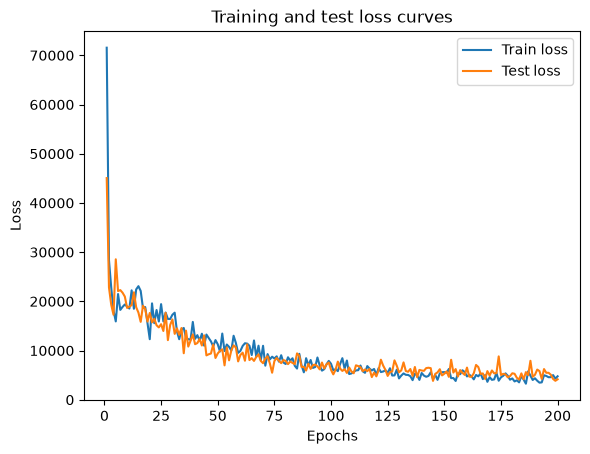

In [37]:
plot_loss(num_epochs=200, train_loss_values=history['train_loss'], val_loss_values=history['val_loss'])